In [2]:
import rasterio
import matplotlib.pyplot as plt
import os 
import numpy as np
import gc
import glob

In [3]:
import tensorflow as tf
import keras

I0000 00:00:1781945129.737887    1494 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781945130.251394    1494 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781945131.772047    1494 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [72]:
dataset_DIR = "/home/avinash/ISRO/IR_to_RGB/Dataset"
output_DIR = "/home/avinash/ISRO/IR_to_RGB/Saved_Patches"
scene_folders = os.listdir(dataset_DIR)

In [16]:
os.makedirs(output_DIR, exist_ok=True)

In [14]:
def normalize(band):

    pLow = np.percentile(band, 2)
    pHigh = np.percentile(band, 98)

    band_Normalized = (band - pLow)/(pHigh- pLow)

    band_Clipped = np.clip(band_Normalized, 0, 1)

    return band_Clipped

In [22]:
def extract_patches(IR, RED, GREEN, BLUE, scene_name, PATCH_SIZE = 256):
    H, W = IR.shape[0], IR.shape[1]
    patch_count = 0


    for row in range(0, H - PATCH_SIZE, PATCH_SIZE):
        for col in range(0, W - PATCH_SIZE, PATCH_SIZE):
            ir_patch = IR[row: row + PATCH_SIZE, col: col + PATCH_SIZE]

            if ir_patch.min() == 0:
                continue
            red_patch = RED[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            green_patch = GREEN[row: row + PATCH_SIZE, col: col + PATCH_SIZE]
            blue_patch = BLUE[row: row + PATCH_SIZE, col: col + PATCH_SIZE]

            rgb_patch = np.stack([red_patch, green_patch, blue_patch], axis=-1)
            os.makedirs(os.path.join(output_DIR, f"{scene_name}"),exist_ok=True)
            np.save(os.path.join(output_DIR, f"{scene_name}",f"ir_{patch_count}.npy"), arr=ir_patch)
            np.save(os.path.join(output_DIR, f"{scene_name}",f"rgb_{patch_count}.npy"), arr=rgb_patch)
            patch_count += 1
    return patch_count



In [23]:
total_saved_patches = 0

for scene in scene_folders:
    print(f"Extracting from scene: ", scene)
    scene_path = os.path.join(dataset_DIR, scene)

    with rasterio.open(f'{scene_path}/lwir11.tif') as src:
        IR = src.read(1)
    with rasterio.open(f'{scene_path}/red.tif') as src:
        RED = src.read(1)
    with rasterio.open(f'{scene_path}/green.tif') as src:
        GREEN = src.read(1)
    with rasterio.open(f'{scene_path}/blue.tif') as src:
        BLUE = src.read(1)

    
    redNorm = normalize(RED)
    greenNorm = normalize(GREEN)
    blueNorm = normalize(BLUE)
    irNorm = normalize(IR)

    saved_count = extract_patches(irNorm, redNorm, greenNorm, blueNorm, scene)
    total_saved_patches += saved_count

    del IR, RED, GREEN, BLUE
    del redNorm, greenNorm, blueNorm, irNorm
    gc.collect()


print("Total pairs across all scenes:", total_saved_patches)


Extracting from scene:  sample_16
Extracting from scene:  sample_4
Extracting from scene:  sample_11
Extracting from scene:  sample_5
Extracting from scene:  sample_13
Extracting from scene:  sample_8
Extracting from scene:  sample_17
Extracting from scene:  sample_19
Extracting from scene:  sample_1
Extracting from scene:  sample_9
Extracting from scene:  sample_15
Extracting from scene:  sample_3
Extracting from scene:  sample_20
Extracting from scene:  sample_2
Extracting from scene:  sample_14
Extracting from scene:  sample_18
Extracting from scene:  sample_10
Extracting from scene:  sample_7
Extracting from scene:  sample_6
Extracting from scene:  sample_12
Total pairs across all scenes: 11262


In [29]:
def collect_patch_paths(root_dir):
    sample_files = os.listdir(root_dir)
    pairs = []

    for sample in sample_files:
        sample_path = os.path.join(root_dir, sample)
        ir_files = glob.glob(os.path.join(sample_path, "ir_*.npy"))

        for ir_path in ir_files:
            rgb_path = ir_path.replace("ir_", "rgb_")

            pairs.append((ir_path, rgb_path))

    return pairs

In [31]:
pairs = collect_patch_paths("/home/avinash/ISRO/IR_to_RGB/Saved_Patches")
print("Total pairs:", len(pairs))
print(pairs[0])

Total pairs: 11262
('/home/avinash/ISRO/IR_to_RGB/Saved_Patches/sample_16/ir_241.npy', '/home/avinash/ISRO/IR_to_RGB/Saved_Patches/sample_16/rgb_241.npy')


In [30]:
def data_generator(pairs):
    for ir_pair, rgb_path in pairs:
        ir = np.load(ir_pair)
        ir = np.expand_dims(ir, axis=-1)
        rgb = np.load(rgb_path)

        yield ir, rgb

In [32]:
gen = data_generator(pairs)
ir_sample, rgb_sample = next(gen)
print(ir_sample.shape, rgb_sample.shape)

(256, 256, 1) (256, 256, 3)


In [33]:
def make_dataset(pairs, batch_size=4):
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(pairs),
        output_signature=(
            tf.TensorSpec(shape=(256, 256, 1)),
            tf.TensorSpec(shape=(256, 256, 3))
        )
    )
    dataset = dataset.shuffle(buffer_size=500)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)    
    return dataset

In [34]:
train_ds = make_dataset(pairs, batch_size=4)

for ir_batch, rgb_batch in train_ds.take(1):
    print("IR batch shape:", ir_batch.shape)
    print("RGB batch shape:", rgb_batch.shape)

I0000 00:00:1781946311.976670    5536 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.


IR batch shape: (4, 256, 256, 1)
RGB batch shape: (4, 256, 256, 3)


In [4]:
tf.keras.mixed_precision.set_global_policy('mixed_float16')

In [5]:
def downsample_block(filters, size=4):
    block = tf.keras.Sequential()
    block.add(tf.keras.layers.Conv2D(filters, size, strides=2, padding='same'))
    block.add(tf.keras.layers.BatchNormalization())
    block.add(tf.keras.layers.LeakyReLU())
    return block


In [6]:
block = downsample_block(64)
test_input = tf.random.normal([1, 256, 256, 1])  # fake IR batch of 1
output = block(test_input)
print(output.shape)

W0000 00:00:1781945229.346469    1494 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1781945229.351410    1494 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1781945229.511124    1494 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5199 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a
E0000 00:00:1781945229.714319    1494 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1781945230.362505    1494 cuda_dnn.cc:461] Loaded cuDNN version 92100


(1, 128, 128, 64)


In [7]:
def build_encoder():
    filter_list = [64, 128, 256, 512, 512, 512, 512, 512]
    blocks = []
    for filter in filter_list:
        blocks.append(downsample_block(filter))

    return blocks


In [8]:
encoder_blocks = build_encoder()


for i, block in enumerate(encoder_blocks):
    x = block(x)
    print(f"Shape of input after {i+1} block: {x.shape}")

NameError: name 'x' is not defined

In [75]:
def decoder_block(filters, dropout, size = 4):
    block = tf.keras.Sequential()
    block.add(tf.keras.layers.UpSampling2D(size=2))
    block.add(tf.keras.layers.Conv2D(filters, size, strides=1, padding='same'))
    block.add(tf.keras.layers.BatchNormalization())
    if dropout:
        block.add(tf.keras.layers.Dropout(0.5))
    block.add(tf.keras.layers.ReLU())

    return block

In [ ]:
def build_decoder():
    filter_list = [512, 512, 512, 512, 256, 128, 64]
    
    blocks = []
    for filter in filter_list:
        blocks.append(decoder_block(filter, False))
    return blocks

In [11]:
decoder_blocks = build_decoder()
for i, block in enumerate(decoder_blocks):
    x = block(x)
    print(f"Shape of input after {i+1} block: {x.shape}")

NameError: name 'x' is not defined

In [12]:
final_output_layer = tf.keras.layers.Conv2DTranspose(
    filters=3, 
    kernel_size=4,
    strides=2,
    padding='same', 
    activation='sigmoid' # Use 'sigmoid' for binary mask (0 or 1), or 'softmax' if multi-class
)

# 3. Pass x through the final layer
required_output = final_output_layer(x)

print(f"Final output shape: {required_output.shape}")
# Expected Output: (4, 1024, 1024, 1)

NameError: name 'x' is not defined

Generator function

In [ ]:
def build_generator():
    tf.keras.backend.clear_session()

    inputs = tf.keras.Input(shape=( 256, 256 ,1))

    x = inputs
    skip_outputs = []
    
    encoder_blocks = build_encoder()


    for i, block in enumerate(encoder_blocks):
        x = block(x)
        print(f"Shape of input after {i+1} block: {x.shape}")
        skip_outputs.append(x)
    
    print("No of skip outputs saved: ", len(skip_outputs))
    for i, s in enumerate(skip_outputs):
        print(f"skip {i}: {s.shape}")
    
    skips_for_decoder = list(reversed(skip_outputs[:-1]))
    decoder_blocks = build_decoder()
    for idx, (block, skip) in enumerate(zip(decoder_blocks, skips_for_decoder)):
        x = block(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        print(f"Shape after Up-block {idx+1} (with concat): {x.shape}")

    final_layer = tf.keras.Sequential([
    tf.keras.layers.UpSampling2D(size=2),
    tf.keras.layers.Conv2D(3, 4, strides=1, padding='same', activation='sigmoid')
])
    outputs = final_layer(x)
    print("Final Output Shape: ",outputs.shape)
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    return model

generator = build_generator()
print("/n")
generator.summary()



Shape of input after 1 block: (None, 128, 128, 64)
Shape of input after 2 block: (None, 64, 64, 128)
Shape of input after 3 block: (None, 32, 32, 256)
Shape of input after 4 block: (None, 16, 16, 512)
Shape of input after 5 block: (None, 8, 8, 512)
Shape of input after 6 block: (None, 4, 4, 512)
Shape of input after 7 block: (None, 2, 2, 512)
Shape of input after 8 block: (None, 1, 1, 512)
No of skip outputs saved:  8
skip 0: (None, 128, 128, 64)
skip 1: (None, 64, 64, 128)
skip 2: (None, 32, 32, 256)
skip 3: (None, 16, 16, 512)
skip 4: (None, 8, 8, 512)
skip 5: (None, 4, 4, 512)
skip 6: (None, 2, 2, 512)
skip 7: (None, 1, 1, 512)
Shape after Up-block 1 (with concat): (None, 2, 2, 1024)
Shape after Up-block 2 (with concat): (None, 4, 4, 1024)
Shape after Up-block 3 (with concat): (None, 8, 8, 1024)
Shape after Up-block 4 (with concat): (None, 16, 16, 1024)
Shape after Up-block 5 (with concat): (None, 32, 32, 512)
Shape after Up-block 6 (with concat): (None, 64, 64, 256)
Shape after Up-

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      1,344 │ input_layer[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,712 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,568 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 16, 16,    │  2,099,712 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 8, 8, 512) │  4,196,864 │ sequential_3[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_5        │ (None, 4, 4, 512) │  4,196,864 │ sequential_4[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_6        │ (None, 2, 2, 512) │  4,196,864 │ sequential_5[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_7        │ (None, 1, 1, 512) │  4,196,864 │ sequential_6[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_8        │ (None, 2, 2, 512) │  4,196,864 │ sequential_7[0][… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 2,      │          0 │ sequential_8[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_6[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_9        │ (None, 4, 4, 512) │  8,391,168 │ concatenate[0][0] │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 4, 4,      │          0 │ sequential_9[0][… │
│ (Concatenate)       │ 1024)             │            │ sequential_5[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_10       │ (None, 8, 8, 512) │  8,391,168 │ concatenate_1[0]… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 8, 8,      │          0 │ sequential_10[0]… │
│ (Concatenate)       │ 1024)             │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_11       │ (None, 16, 16,    │  8,391,168 │ concatenate_2[0]… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 16, 16,    │          0 │ sequential_11[0]

 Total params: 54,429,571 (207.63 MB)

 Trainable params: 54,418,563 (207.59 MB)

 Non-trainable params: 11,008 (43.00 KB)

In [26]:
import tensorflow as tf
import gc

# 1. Clear the Keras session (destroys the old graphs)
tf.keras.backend.clear_session()

# 2. Force Python's garbage collector to free up unreferenced memory
gc.collect()

# Now it is safe to build your model again


0

In [14]:
def downsample_block(filters, strides, ADD_BatchNorm = True):
    block = tf.keras.Sequential()
    block.add(tf.keras.layers.Conv2D(filters, 4, strides, padding='same'))
    if ADD_BatchNorm:
        block.add(tf.keras.layers.BatchNormalization())
    block.add(tf.keras.layers.LeakyReLU())

    return block

Discriminator Function

In [15]:

def build_discriminator():
    tf.keras.backend.clear_session()
    
    ir_input = tf.keras.Input((256, 256, 1))
    rgb_input = tf.keras.Input((256, 256, 3))
    x = tf.keras.layers.Concatenate()([ir_input, rgb_input])
    x = downsample_block(64, 2, False)(x)
    x = downsample_block(128, 2)(x)
    x = downsample_block(256, 2)(x)
    x = downsample_block(512, 1)(x)
    
    final_layer = tf.keras.layers.Conv2D(1, 4, 1, 'same')

    outputs = final_layer(x)
    
    model = tf.keras.Model(inputs=[ir_input, rgb_input], outputs=outputs)
    return model



In [16]:
discriminator = build_discriminator()
discriminator.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256, 256,  │          0 │ input_layer[0][0… │
│ (Concatenate)       │ 4)                │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 128, 128,  │      4,160 │ concatenate[0][0] │
│ (Sequential)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_1        │ (None, 64, 64,    │    131,712 │ sequential[0][0]  │
│ (Sequential)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_2        │ (None, 32, 32,    │    525,568 │ sequential_1[0][… │
│ (Sequential)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 32, 32,    │  2,099,712 │ sequential_2[0][… │
│ (Sequential)        │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32, 1) │      8,193 │ sequential_3[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,769,345 (10.56 MB)

 Trainable params: 2,767,553 (10.56 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [17]:
test_ir = tf.random.normal([4, 256, 256, 1])
test_rgb = tf.random.normal([4, 256, 256, 3])
output = discriminator([test_ir, test_rgb])
print("Output shape:", output.shape)

Output shape: (4, 32, 32, 1)


Discriminator Loss


In [18]:
loss_object = tf.losses.BinaryCrossentropy(from_logits=True)

def discriminator_loss(real_output, fake_output):
    real_loss = loss_object(tf.ones_like(real_output) * 0.9, real_output)
    fake_loss = loss_object(tf.ones_like(fake_output), fake_output)

    total_loss = real_loss + fake_loss
    return total_loss

Generator Loss

In [19]:
LAMBDA = 100

In [20]:
def generator_loss(disc_fake_output, generated_rgb, target_rgb):
    adverserial_loss = loss_object(tf.ones_like(disc_fake_output), disc_fake_output)

    L1_loss = tf.reduce_mean(tf.abs(generated_rgb - target_rgb))

    total_loss = adverserial_loss + LAMBDA * L1_loss

    return total_loss

In [22]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

generator_optimizer = tf.keras.mixed_precision.LossScaleOptimizer(generator_optimizer)
discriminator_optimizer = tf.keras.mixed_precision.LossScaleOptimizer(discriminator_optimizer)

In [36]:
@tf.function
def training_loop(ir_batch, real_rgb_batch):

    with tf.GradientTape() as disc_tape, tf.GradientTape() as gen_tape:

        fake_rgb = generator(ir_batch, training=True)

        disc_real_output = discriminator([ir_batch, real_rgb_batch], training=True)
        disc_fake_output = discriminator([ir_batch, fake_rgb], training=True)

        gen_loss = generator_loss(disc_fake_output, fake_rgb, real_rgb_batch)
        disc_loss = discriminator_loss(disc_real_output, disc_fake_output)

        scaled_gen_loss = generator_optimizer.scale_loss(gen_loss)
        scaled_disc_loss = discriminator_optimizer.scale_loss(disc_loss)

    scaled_generator_gradients = gen_tape.gradient(scaled_gen_loss, generator.trainable_variables)
    scaled_discriminator_gradients = disc_tape.gradient(scaled_disc_loss, discriminator.trainable_variables)

    

    generator_optimizer.apply_gradients(zip(scaled_generator_gradients, generator.trainable_variables ))
    discriminator_optimizer.apply_gradients(zip(scaled_discriminator_gradients, discriminator.trainable_variables))

    return gen_loss, disc_loss

In [37]:
for ir_batch, rgb_batch in train_ds.take(1):
    g_loss, d_loss = training_loop(ir_batch, rgb_batch)
    print("Generator loss:", g_loss.numpy())
    print("Discriminator loss:", d_loss.numpy())

Generator loss: 23.720615
Discriminator loss: 1.4074461


In [46]:
import random

subset_pairs = random.sample(pairs, 2500)
train_ds_small = make_dataset(subset_pairs, 8)

In [39]:
import time
tf.keras.backend.clear_session()
def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()
        
        for ir_batch, rgb_batch in dataset:
            gen_loss, disc_loss = training_loop(ir_batch, rgb_batch)
        
        print(f"Epoch {epoch+1}/{epochs} — Gen loss: {gen_loss:.4f}, Disc loss: {disc_loss:.4f}, Time: {time.time()-start:.1f}s")

In [ ]:
train(train_ds, epochs=1)

Epoch 1/1 — Gen loss: 3.4282, Disc loss: 0.3272, Time: 280.4s


In [53]:
checkpoint_dir = '/home/avinash/ISRO/IR_to_RGB/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)

def train(dataset, epochs, save_every=10):
    for epoch in range(epochs):
        start = time.time()
        
        for ir_batch, rgb_batch in dataset:
            gen_loss, disc_loss = training_loop(ir_batch, rgb_batch)
        
        print(f"Epoch {epoch+1}/{epochs} — Gen loss: {gen_loss:.4f}, Disc loss: {disc_loss:.4f}, Time: {time.time()-start:.1f}s")
        
        if (epoch + 1) % save_every == 0:
            generator.save_weights(f'{checkpoint_dir}/generator_epoch_{epoch+1}.weights.h5')
            print(f"  → Saved checkpoint at epoch {epoch+1}")

In [54]:
train(train_ds_small, 100, 15)

Epoch 1/100 — Gen loss: 13.1730, Disc loss: 0.3331, Time: 46.0s
Epoch 2/100 — Gen loss: 8.2091, Disc loss: 0.3273, Time: 53.1s
Epoch 3/100 — Gen loss: 6.3529, Disc loss: 0.3264, Time: 48.3s
Epoch 4/100 — Gen loss: 4.3613, Disc loss: 0.3263, Time: 46.4s
Epoch 5/100 — Gen loss: 3.5086, Disc loss: 0.3385, Time: 44.8s
Epoch 6/100 — Gen loss: 15.3904, Disc loss: 0.3265, Time: 47.9s
Epoch 7/100 — Gen loss: 4.3524, Disc loss: 0.3264, Time: 48.1s
Epoch 8/100 — Gen loss: 4.5601, Disc loss: 0.3280, Time: 53.5s
Epoch 9/100 — Gen loss: 7.4600, Disc loss: 0.3265, Time: 45.9s
Epoch 10/100 — Gen loss: 4.6774, Disc loss: 0.3335, Time: 45.1s
Epoch 11/100 — Gen loss: 4.0590, Disc loss: 0.3417, Time: 49.8s
Epoch 12/100 — Gen loss: 6.6348, Disc loss: 0.3271, Time: 45.0s
Epoch 13/100 — Gen loss: 3.5946, Disc loss: 0.3270, Time: 44.5s
Epoch 14/100 — Gen loss: 4.2751, Disc loss: 0.3253, Time: 43.9s
Epoch 15/100 — Gen loss: 4.8311, Disc loss: 0.3279, Time: 48.1s
  → Saved checkpoint at epoch 15
Epoch 16/100 —

In [42]:
import matplotlib.pyplot as plt

def show_sample(generator, ir_patch, real_rgb_patch):
    # ir_patch shape: (256, 256, 1) -> need to add batch dimension
    ir_input = tf.expand_dims(ir_patch, axis=0)   # (1, 256, 256, 1)
    
    fake_rgb = generator(ir_input, training=False)   # (1, 256, 256, 3)
    fake_rgb = fake_rgb[0]   # remove batch dimension -> (256, 256, 3)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(ir_patch[:, :, 0], cmap='gray')
    axes[0].set_title("Input IR")
    axes[0].axis('off')
    
    axes[1].imshow(fake_rgb.numpy())
    axes[1].set_title("Generated RGB")
    axes[1].axis('off')
    
    axes[2].imshow(real_rgb_patch.numpy())
    axes[2].set_title("Ground Truth RGB")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

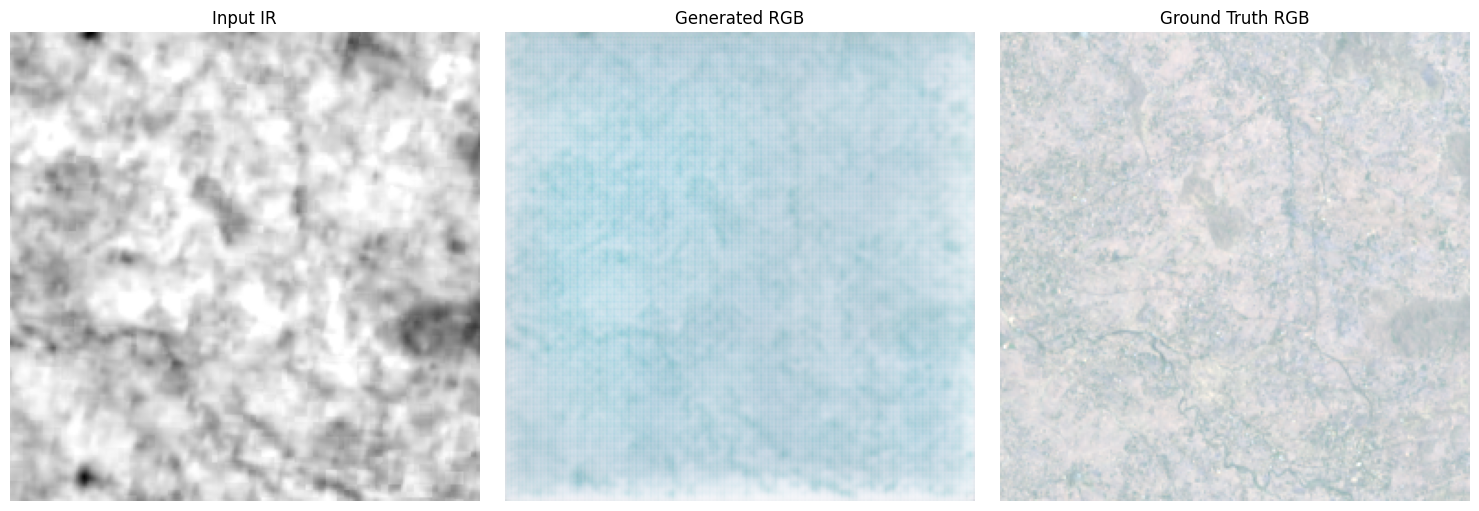

In [65]:
for ir_batch, rgb_batch in train_ds_small.take(50000):
    show_sample(generator, ir_batch[0], rgb_batch[0])
    break

In [83]:
tf.keras.backend.clear_session()

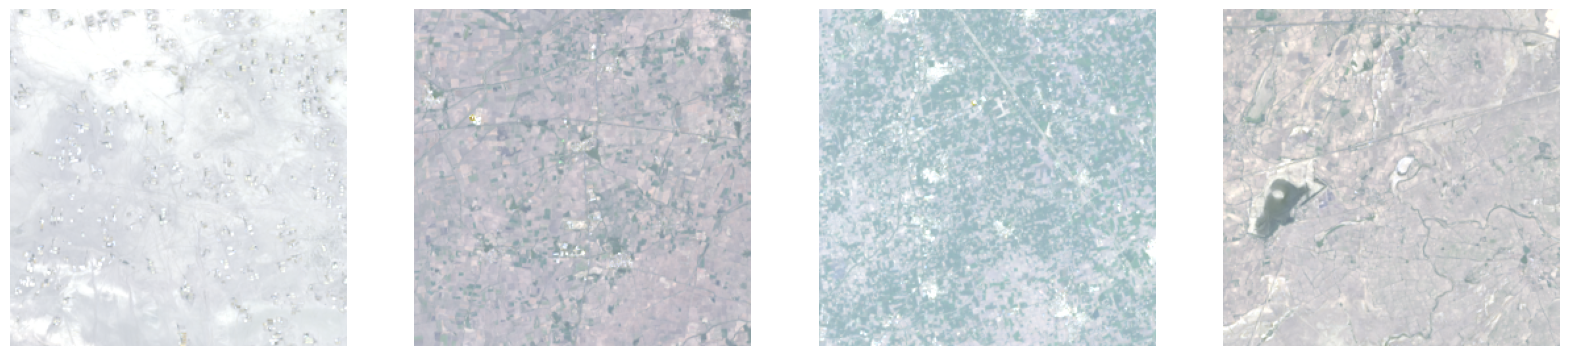

In [70]:
import matplotlib.pyplot as plt

# pick a few random ground-truth RGB patches directly from your saved .npy files
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i in range(4):
    rgb = np.load(pairs[i*500][1])   # grab rgb_path from a few different patches
    axes[i].imshow(rgb)
    axes[i].axis('off')
plt.show()

In [74]:
import os

scene_folders = os.listdir(dataset_DIR)
for scene in scene_folders[:]:   # check a handful
    with rasterio.open(f'{dataset_DIR}/{scene}/red.tif') as src:
        red = src.read(1)
    valid = red[red != 0]
    print(f"{scene}: min={valid.min()}, max={valid.max()}, range={valid.max()-valid.min()}, std={valid.std():.1f}")

sample_16: min=2610, max=58426, range=55816, std=1844.1
sample_4: min=3701, max=48456, range=44755, std=1376.3
sample_11: min=4633, max=55041, range=50408, std=1929.6
sample_5: min=6151, max=53933, range=47782, std=1644.2
sample_13: min=4511, max=55999, range=51488, std=1854.9
sample_8: min=3894, max=46468, range=42574, std=1433.8
sample_17: min=1959, max=41523, range=39564, std=1455.5
sample_19: min=4195, max=51944, range=47749, std=1746.2
sample_1: min=5402, max=46903, range=41501, std=2979.1
sample_9: min=5002, max=54921, range=49919, std=1871.0
sample_15: min=2097, max=58683, range=56586, std=1378.1
sample_3: min=5884, max=54260, range=48376, std=1594.6
sample_20: min=3923, max=54699, range=50776, std=1193.4
sample_2: min=7407, max=49502, range=42095, std=1218.7
sample_14: min=1056, max=57888, range=56832, std=2530.7
sample_18: min=4290, max=31220, range=26930, std=1225.7
sample_10: min=3556, max=46955, range=43399, std=1357.6
sample_7: min=7540, max=53872, range=46332, std=1529.5
